In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = "/projectnb/sparkgrp/dd4g-muckrock-patient-safety/FINALd1234.csv"
df = pd.read_csv(file_path)

In [27]:
df.sample(20)

,DEVICE_REPORT_PRODUCT_CODE,MDR_REPORT_KEY,GENERIC_NAME,BRAND_NAME,MANUFACTURER_D_NAME,DATE_RECEIVED,TEXT_LENGTH,YEAR,event_date_initiated,recall_status,reason_for_recall,problem_term,month
16529118,DZE,21680399,ENDOSSEOUS DENTAL IMPLANT,"BLT Ø3.3MM NC, SLA® 8MM, TIZR, LOXIM",INSTITUT STRAUMANN AG,2025-03-24,1211,2025,2012-03-22,Terminated,this zimmer dental voluntary device recall res...,NaN,2025-03
8586072,LGW,13458256,PERCUTANEOUS LEAD,"OCTRODE LEAD KIT, 60CM LENGTH",ST. JUDE MEDICAL - NEUROMODULATION (PUERTO RIC...,2022-02-04,563,2022,2004-11-11,Terminated,a burn injury was sustained by a patient that ...,charging problem,2022-02
16050938,QFG,21179737,ALTERNATE CONTROLLER ENABLED INSULIN INFUSION ...,TANDEM MOBI INSULIN PUMP WITH INTEROPERABLE TE...,TANDEM DIABETES CARE,2025-01-17,388,2025,2024-03-05,"Open, Classified","during normal use, the mobile app version 2.7 ...",NaN,2025-01
14105339,LWR,19157596,"HEART-VALVE, NON-ALLOGRAFT TISSUE",FREESTYLE AORTIC ROOT BIOPROSTHESIS,MEDTRONIC HEART VALVES DIVISION,2024-04-22,905,2024,2020-07-29,Terminated,livanova received complaints indicating the im...,NaN,2024-04
7739197,DZE,12591880,ENDOSSEOUS DENTAL IMPLANT,"BLT 4.8MM RC, SLACTIVE 10MM, TIZR, NTP",INSTITUT STRAUMANN AG,2021-10-07,359,2021,2012-03-22,Terminated,this zimmer dental voluntary device recall res...,NaN,2021-10
16828987,QLG,21992764,FLASH GLUCOSE MONITORING SYSTEM,FREESTYLE LIBRE 2,ABBOTT DIABETES CARE INC,2025-05-09,3910,2025,2023-02-13,"Open, Classified",lithium-ion batteries in glucose monitoring sy...,NaN,2025-05
4473877,DSQ,9188209,VENTRICULAR (ASSIST) BYPASS,HEARTWARE VENTRICULAR ASSIST SYSTEM - DRIVELINE,"HEARTWARE, INC.",2019-10-14,2721,2019,2009-04-23,Terminated,"ipulse console sc1035 displayed a ""low pressur...",pumping stopped,2019-10
3130348,DSQ,7768488,VENTRICULAR (ASSISST) BYPASS,HEARTWARE VENTRICULAR ASSIST SYSTEM-PUMP,"HEARTWARE, INC.",2018-08-09,1353,2018,2009-04-23,Terminated,"ipulse console sc1035 displayed a ""low pressur...",pumping stopped,2018-08
3181613,BSZ,7822696,ANESTHESIA GAS MACHINE,AESPIRE 7900,"DATEX-OHMEDA, INC.",2018-08-28,478,2018,2012-04-29,Terminated,accutron is recalling the flowmeter (analgesia...,air/gas in device,2018-08
5088887,GAW,9832091,"SUTURE, NONABSORBABLE, SYNTHETIC",PRLNE BLU 18IN 8-0 D/A BV130-5 EP,ETHICON INC.,2020-03-13,918,2020,2018-05-07,Terminated,the needle associated with certain suture prod...,inadequate instructions for healthcare profess...,2020-03


In [30]:
df.iloc[3181613]

DEVICE_REPORT_PRODUCT_CODE                                                  BSZ
MDR_REPORT_KEY                                                          7822696
GENERIC_NAME                                             ANESTHESIA GAS MACHINE
BRAND_NAME                                                         AESPIRE 7900
MANUFACTURER_D_NAME                                          DATEX-OHMEDA, INC.
DATE_RECEIVED                                               2018-08-28 00:00:00
TEXT_LENGTH                                                                 478
YEAR                                                                       2018
event_date_initiated                                                 2012-04-29
recall_status                                                        Terminated
reason_for_recall             accutron is recalling the flowmeter (analgesia...
problem_term                                                  air/gas in device
month                                   

In [22]:
df['DATE_RECEIVED'] = pd.to_datetime(df['DATE_RECEIVED'], errors='coerce')
df['month'] = df['DATE_RECEIVED'].dt.to_period('M')

monthly_counts = (
    df.groupby(['month', 'GENERIC_NAME'])
    .size()
    .reset_index(name='complaint_count')
)

In [23]:
monthly_counts.sample(20)

,month,GENERIC_NAME,complaint_count
275536,2022-01,DYNAMIC IMPLANT SP 5X13,4
194714,2020-01,LOFRIC CLASSIC,1
360833,2024-02,"COALITION SPACER, 12MM X 14MM, 7 DEGREE, 5MM",1
306322,2022-10,CUSTOM KIT,1
389175,2024-09,"SURGEON SIDE CONSOLE, RECERTIFIED",2
77299,2017-03,BIOLOX DELTA CERAMIC FEMORAL HEAD,8
324614,2023-03,"MICROSCOPE, OPERATING & ACC., AC-POWERED, OPHT...",1
233793,2021-01,COMPUTER VITEK® 2 HP RP5700 R,1
93416,2017-08,"CIRCUIT, BREATHING (W CONNECTOR, ADAPTOR, Y PI...",3
58077,2016-08,"PROSTHESIS, INTERVERTEBRAL DISC",3


In [24]:
top_devices = (
    monthly_counts
    .sort_values(['month','complaint_count'], ascending=[True, False])
    .groupby('month')
    .head(5)
)

#top 5 device names with the most complaints each month 

In [25]:
top_devices

,month,GENERIC_NAME,complaint_count
1336,2015-01,INSULIN INFUSION PUMP / SENSOR AUGMENTED,10423
1065,2015-01,"GENERATOR, OXYGEN, PORTABLE",7029
1335,2015-01,INSULIN INFUSION PUMP,4054
1082,2015-01,GLUCOSE MONITORING SYS/KIT,3850
1843,2015-01,OZO,2988
...,...,...,...
445347,2025-12,ENDOSSEOUS DENTAL IMPLANT,59275
444192,2025-12,ALTERNATE CONTROLLER ENABLED INSULIN INFUSION ...,32563
444856,2025-12,CONTINUOUS GLUCOSE MONITOR,22311
444362,2025-12,"AUTOMATED INSULIN DOSING DEVICE SYSTEM, SINGLE...",13621


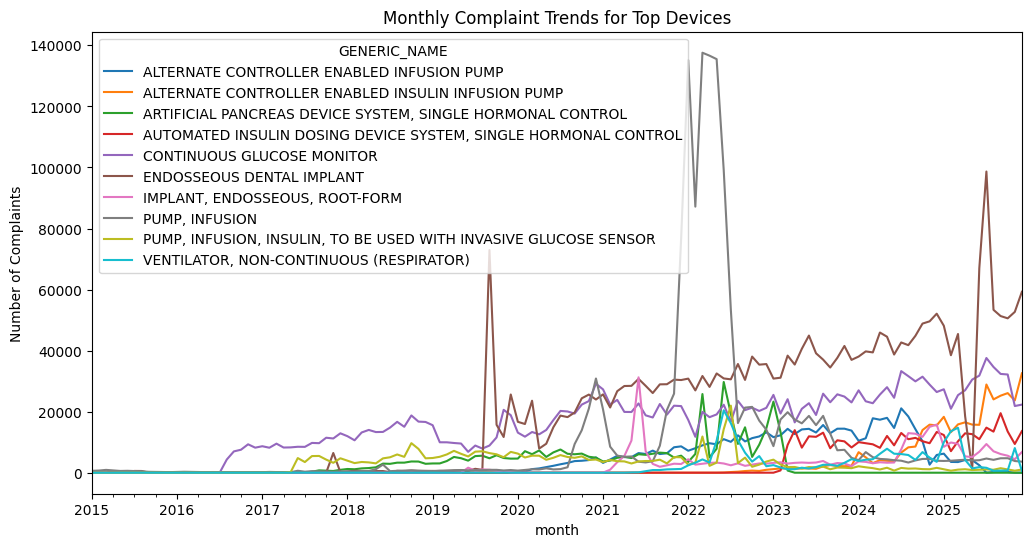

In [26]:
top10 = df['GENERIC_NAME'].value_counts().head(10).index #top 10 most recurring values in dataset 

trend = (
    df[df['GENERIC_NAME'].isin(top10)]
    .groupby(['month','GENERIC_NAME'])
    .size()
    .unstack(fill_value=0)
)

trend.plot(figsize=(12,6))
plt.title("Monthly Complaint Trends for Top Devices")
plt.ylabel("Number of Complaints")
plt.show()

In [32]:
problem_counts = df['problem_term'].value_counts().reset_index()
problem_counts.columns = ['problem_term', 'count']

#top 10 problems
top_problems = problem_counts.head(10)
print(top_problems)

                     problem_term   count
0                 failure to pump  477504
1                charging problem  442974
2             valve(s), defective  251230
3        deflation, cause unknown  250506
4                 battery failure  228454
5             lead(s), shock from  219800
6         failure to run on ac/dc  159929
7                 pumping stopped  137321
8             delayed charge time  124667
9  premature discharge of battery  121118


In [41]:
#status = recall 
recall_statuses = ['Terminated', 'Completed']

#recalled complaints
recalled_df = df[df['recall_status'].isin(recall_statuses)]

#problem terms that led to recall 
recall_problem_counts = recalled_df['problem_term'].value_counts().reset_index()
recall_problem_counts.columns = ['problem_term', 'recall_count']

#total prob term sum 
problem_counts = df['problem_term'].value_counts().reset_index()
problem_counts.columns = ['problem_term', 'count']

#recall rate 
problem_analysis = problem_counts.merge(recall_problem_counts, on='problem_term', how='left').fillna(0)
problem_analysis['recall_rate'] = problem_analysis['recall_count'] / problem_analysis['count']

#problem terms by recall rate 
top_recall_problems = problem_analysis.sort_values(by='recall_rate', ascending=False).head(10)
print(top_recall_problems)

#makes sense, data that hasnt been recalled wouldn't exist 

                           problem_term   count  recall_count  recall_rate
318  intermittent communication failure       1           1.0          1.0
0                       failure to pump  477504      477504.0          1.0
1                      charging problem  442974      442974.0          1.0
2                   valve(s), defective  251230      251230.0          1.0
3              deflation, cause unknown  250506      250506.0          1.0
316         protective measures problem       1           1.0          1.0
5                   lead(s), shock from  219800      219800.0          1.0
6               failure to run on ac/dc  159929      159929.0          1.0
7                       pumping stopped  137321      137321.0          1.0
8                   delayed charge time  124667      124667.0          1.0


In [40]:
df['recall_status'].unique()

array(['Terminated', 'Open, Classified', 'Completed'], dtype=object)

do recalls stem from complaints, or other fda identified systems? 

in this month, these products had most issues/complains 